In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [5]:
df = pd.read_excel('../data/ai_workforce_displacement_global_2020_2026.xlsx')

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/ai_workforce_displacement_global_2020_2026.xlsx'

In [6]:
import os

os.listdir('../data')

[]

In [7]:
import os
os.listdir('../data')

['ai_workforce_displacement_global_2020_2026.csv']

In [8]:
df = pd.read_csv('../data/ai_workforce_displacement_global_2020_2026.csv')

df.head()

,record_id,country,iso3_code,region,income_group,year,quarter,quarter_label,industry_sector,sector_automation_risk_score,...,pct_sector_workforce_new_roles_created,net_workforce_change_pct,ai_cited_layoff_announcements,ai_skill_wage_premium_pct,pct_workforce_female,pct_displaced_roles_female,reskilling_programs_count,govt_ai_policy_score_1_to_10,ai_tool_adoption_pct,data_source_notes
0,1,United States,USA,North America,High Income,2020,1,2020-Q1,Technology & Software,0.382,...,0.0348,-0.0058,32,0.311,0.28,0.275,52,6.4,0.280,Research-calibrated synthetic data. Grounded i...
1,2,United States,USA,North America,High Income,2020,1,2020-Q1,Finance & Banking,0.608,...,0.0423,-0.0094,51,0.304,0.48,0.511,39,6.5,0.559,Research-calibrated synthetic data. Grounded i...
2,3,United States,USA,North America,High Income,2020,1,2020-Q1,Healthcare & Life Sciences,0.198,...,0.0168,-0.0008,4,0.278,0.72,0.707,37,6.8,0.202,Research-calibrated synthetic data. Grounded i...
3,4,United States,USA,North America,High Income,2020,1,2020-Q1,Manufacturing & Industry,0.720,...,0.0642,-0.0282,47,0.268,0.29,0.310,50,6.8,0.655,Research-calibrated synthetic data. Grounded i...
4,5,United States,USA,North America,High Income,2020,1,2020-Q1,Retail & E-Commerce,0.676,...,0.0374,-0.0293,31,0.313,0.54,0.547,37,6.2,0.542,Research-calibrated synthetic data. Grounded i...


In [9]:
df.shape

(20800, 23)

In [10]:
df.columns

Index(['record_id', 'country', 'iso3_code', 'region', 'income_group', 'year',
       'quarter', 'quarter_label', 'industry_sector',
       'sector_automation_risk_score', 'gdp_per_capita_usd',
       'ai_adoption_index', 'pct_sector_workforce_displaced',
       'pct_sector_workforce_new_roles_created', 'net_workforce_change_pct',
       'ai_cited_layoff_announcements', 'ai_skill_wage_premium_pct',
       'pct_workforce_female', 'pct_displaced_roles_female',
       'reskilling_programs_count', 'govt_ai_policy_score_1_to_10',
       'ai_tool_adoption_pct', 'data_source_notes'],
      dtype='object')

In [11]:
df.isnull().sum()

record_id                                 0
country                                   0
iso3_code                                 0
region                                    0
income_group                              0
year                                      0
quarter                                   0
quarter_label                             0
industry_sector                           0
sector_automation_risk_score              0
gdp_per_capita_usd                        0
ai_adoption_index                         0
pct_sector_workforce_displaced            0
pct_sector_workforce_new_roles_created    0
net_workforce_change_pct                  0
ai_cited_layoff_announcements             0
ai_skill_wage_premium_pct                 0
pct_workforce_female                      0
pct_displaced_roles_female                0
reskilling_programs_count                 0
govt_ai_policy_score_1_to_10              0
ai_tool_adoption_pct                      0
data_source_notes               

In [12]:
df.describe()

,record_id,year,quarter,sector_automation_risk_score,gdp_per_capita_usd,ai_adoption_index,pct_sector_workforce_displaced,pct_sector_workforce_new_roles_created,net_workforce_change_pct,ai_cited_layoff_announcements,ai_skill_wage_premium_pct,pct_workforce_female,pct_displaced_roles_female,reskilling_programs_count,govt_ai_policy_score_1_to_10,ai_tool_adoption_pct
count,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000,20800.000000
mean,10400.500000,2022.769231,2.423077,0.537881,21003.330769,0.692148,0.056155,0.035631,-0.020524,88.346538,0.361570,0.462000,0.497154,34.497981,5.370067,0.372712
std,6004.587135,1.887406,1.115411,0.190345,22048.862955,0.161194,0.044811,0.036586,0.015327,85.198076,0.094132,0.188833,0.222239,22.688847,1.566616,0.166875
min,1.000000,2020.000000,1.000000,0.151000,879.000000,0.169000,0.001800,0.000300,-0.140300,0.000000,0.063000,0.220000,0.213000,2.000000,1.100000,0.037000
25%,5200.750000,2021.000000,1.000000,0.379000,3456.500000,0.591000,0.023300,0.009800,-0.028200,24.000000,0.293000,0.280000,0.290000,13.000000,4.000000,0.231000
50%,10400.500000,2023.000000,2.000000,0.580000,10635.000000,0.720000,0.043400,0.021900,-0.016400,63.000000,0.366000,0.470000,0.493000,30.000000,5.400000,0.365000
75%,15600.250000,2024.000000,3.000000,0.698000,40528.500000,0.821000,0.074900,0.049400,-0.009100,126.000000,0.435000,0.580000,0.610000,53.000000,6.800000,0.498000
max,20800.000000,2026.000000,4.000000,0.855000,99074.000000,0.963000,0.300000,0.279100,-0.000300,603.000000,0.610000,0.790000,0.950000,92.000000,8.800000,0.881000


In [13]:
df.columns

Index(['record_id', 'country', 'iso3_code', 'region', 'income_group', 'year',
       'quarter', 'quarter_label', 'industry_sector',
       'sector_automation_risk_score', 'gdp_per_capita_usd',
       'ai_adoption_index', 'pct_sector_workforce_displaced',
       'pct_sector_workforce_new_roles_created', 'net_workforce_change_pct',
       'ai_cited_layoff_announcements', 'ai_skill_wage_premium_pct',
       'pct_workforce_female', 'pct_displaced_roles_female',
       'reskilling_programs_count', 'govt_ai_policy_score_1_to_10',
       'ai_tool_adoption_pct', 'data_source_notes'],
      dtype='object')

In [14]:
X = df[['ai_adoption_index',
        'sector_automation_risk_score',
        'gdp_per_capita_usd',
        'ai_tool_adoption_pct',
        'govt_ai_policy_score_1_to_10']]

y = df['pct_sector_workforce_displaced']

print(X.head())
print(y.head())

   ai_adoption_index  sector_automation_risk_score  gdp_per_capita_usd  \
0              0.830                         0.382               63514   
1              0.817                         0.608               63514   
2              0.816                         0.198               63514   
3              0.818                         0.720               63514   
4              0.828                         0.676               63514   

   ai_tool_adoption_pct  govt_ai_policy_score_1_to_10  
0                 0.280                           6.4  
1                 0.559                           6.5  
2                 0.202                           6.8  
3                 0.655                           6.8  
4                 0.542                           6.2  
0    0.0406
1    0.0517
2    0.0176
3    0.0924
4    0.0667
Name: pct_sector_workforce_displaced, dtype: float64


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16640, 5)
(4160, 5)


In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model berhasil dilatih")

Model berhasil dilatih


In [17]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 0.015136862719476266
R2 Score: 0.7741571767614042


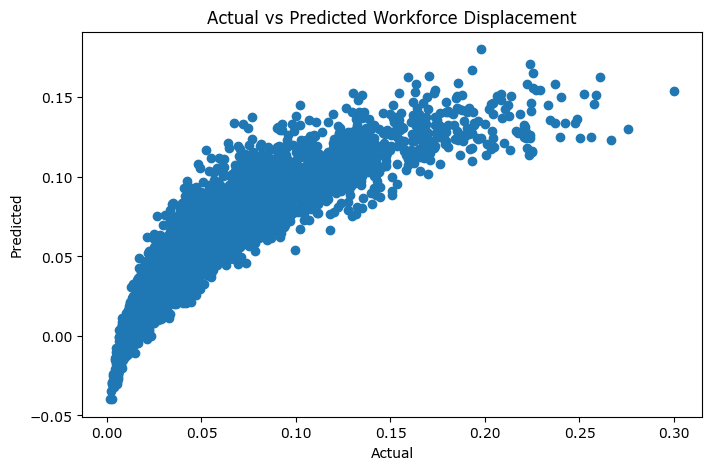

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Workforce Displacement")

plt.show()

In [19]:
import joblib

joblib.dump(model, '../models/ai_workforce_model.pkl')

print("Model berhasil disimpan")

Model berhasil disimpan
